In [2]:
# connection to database 
import pandas as pd
import matplotlib.pyplot as plt
from config import get_engine 
engine=get_engine()

Connected to database: ecommerce_analytics 


In [3]:
# Loading tables from database for analysis
customers_df = pd.read_sql("SELECT * FROM customers", engine)
products_df = pd.read_sql("SELECT * FROM products", engine)
orders_df = pd.read_sql("SELECT * FROM orders", engine)

print("Raw data loaded successfully")

print("\nCustomers shape:", customers_df.shape)
print("Products shape:", products_df.shape)
print("Orders shape:", orders_df.shape)

Raw data loaded successfully

Customers shape: (720, 6)
Products shape: (28, 7)
Orders shape: (17107, 12)


In [4]:
# Basic raw data checks 

print("\n==============================")
print("CUSTOMERS TABLE INFO")
print("==============================")
print(customers_df.info())
print(customers_df.head())

print("\n==============================")
print("PRODUCTS TABLE INFO")
print("==============================")
print(products_df.info())
print(products_df.head())

print("\n==============================")
print("ORDERS TABLE INFO")
print("==============================")
print(orders_df.info())
print(orders_df.head())


CUSTOMERS TABLE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    720 non-null    object
 1   customer_name  720 non-null    object
 2   segment        720 non-null    object
 3   city           720 non-null    object
 4   state          720 non-null    object
 5   region         720 non-null    object
dtypes: object(6)
memory usage: 33.9+ KB
None
  customer_id    customer_name    segment      city        state region
0   CUST-0001     Ayaan Sharma   Consumer   Chennai   Tamil Nadu  South
1   CUST-0002   Krishna Sawant  Corporate    Jaipur    Rajasthan   West
2   CUST-0003       Riya Gupta   Consumer    Ranchi    Jharkhand   East
3   CUST-0004         Sai Jain   Consumer  Dehradun  Uttarakhand  North
4   CUST-0005  Vivaan Kulkarni  Corporate  Gurugram      Haryana  North

PRODUCTS TABLE INFO
<class 'pandas.core.frame.DataF

In [5]:
#Missing value check
print("MISSING VALUES - CUSTOMERS")
print(customers_df.isnull().sum())

print("\nMISSING VALUES - PRODUCTS")
print(products_df.isnull().sum())

print("\nMISSING VALUES - ORDERS")
print(orders_df.isnull().sum())


MISSING VALUES - CUSTOMERS
customer_id      0
customer_name    0
segment          0
city             0
state            0
region           0
dtype: int64

MISSING VALUES - PRODUCTS
product_id      0
category        0
sub_category    0
product_name    0
min_price       0
max_price       0
base_margin     0
dtype: int64

MISSING VALUES - ORDERS
row_id          0
order_id        0
order_date      0
ship_date       0
ship_mode       0
customer_id     0
product_id      0
quantity        0
discount        0
sales           0
profit          0
payment_mode    0
dtype: int64


In [6]:
# Duplicate check
print("DUPLICATE ROWS")
print("\nDuplicate customers:", customers_df.duplicated().sum())
print("Duplicate products:", products_df.duplicated().sum())
print("Duplicate orders:", orders_df.duplicated().sum())

print("\nDuplicate customer_id count:")
print(customers_df["customer_id"].duplicated().sum())

print("\nDuplicate product_id count:")
print(products_df["product_id"].duplicated().sum())

print("\nDuplicate row_id count:")
print(orders_df["row_id"].duplicated().sum())

DUPLICATE ROWS

Duplicate customers: 0
Duplicate products: 0
Duplicate orders: 0

Duplicate customer_id count:
0

Duplicate product_id count:
0

Duplicate row_id count:
0


In [7]:
# Data type check 
print("DATA TYPES - CUSTOMERS")
print(customers_df.dtypes)

print("DATA TYPES - PRODUCTS")
print(products_df.dtypes)

print("DATA TYPES - ORDERS")
print(orders_df.dtypes)

DATA TYPES - CUSTOMERS
customer_id      object
customer_name    object
segment          object
city             object
state            object
region           object
dtype: object
DATA TYPES - PRODUCTS
product_id       object
category         object
sub_category     object
product_name     object
min_price       float64
max_price       float64
base_margin     float64
dtype: object
DATA TYPES - ORDERS
row_id            int64
order_id         object
order_date       object
ship_date        object
ship_mode        object
customer_id      object
product_id       object
quantity          int64
discount        float64
sales           float64
profit          float64
payment_mode     object
dtype: object


In [8]:
#Numerical raw data summary
print("ORDERS NUMERICAL SUMMARY")
print("==============================")
print(orders_df[["quantity", "discount", "sales", "profit"]].describe())

print("\n==============================")
print("PRODUCTS NUMERICAL SUMMARY")
print("==============================")
print(products_df[["min_price", "max_price", "base_margin"]].describe())

ORDERS NUMERICAL SUMMARY
           quantity      discount          sales         profit
count  17107.000000  17107.000000   17107.000000   17107.000000
mean       2.211843      0.080178   25762.666276    2495.185273
std        1.689651      0.084763   54313.196269    6923.728066
min        1.000000      0.000000      75.760000  -47157.800000
25%        1.000000      0.000000    1944.125000     205.705000
50%        2.000000      0.050000    6719.940000     664.960000
75%        3.000000      0.150000   24415.795000    2204.365000
max       10.000000      0.300000  909457.900000  196303.520000

PRODUCTS NUMERICAL SUMMARY
          min_price     max_price  base_margin
count     28.000000     28.000000    28.000000
mean    6695.428571  17031.142857     0.178571
std    11345.181132  24119.149509     0.063638
min       99.000000    499.000000     0.060000
25%      749.000000   2499.000000     0.137500
50%     1499.000000   5999.000000     0.180000
75%     8999.000000  20499.000000     0.22

In [9]:
# Business data checks 
print("\n==============================")
print("NEGATIVE OR INVALID VALUES")
print("==============================")
print("Orders with negative sales:", orders_df[orders_df["sales"] < 0].shape[0])
print("Orders with negative quantity:", orders_df[orders_df["quantity"] < 0].shape[0])
print("Orders with negative profit:", orders_df[orders_df["profit"] < 0].shape[0])
print("Orders with discount greater than 1:", orders_df[orders_df["discount"] > 1].shape[0])

print("\n==============================")
print("DATE CHECK")
print("==============================")
orders_df["order_date_check"] = pd.to_datetime(orders_df["order_date"], errors="coerce")
orders_df["ship_date_check"] = pd.to_datetime(orders_df["ship_date"], errors="coerce")

print("Invalid order_date rows:", orders_df["order_date_check"].isnull().sum())
print("Invalid ship_date rows:", orders_df["ship_date_check"].isnull().sum())

orders_df["ship_days_check"] = (orders_df["ship_date_check"] - orders_df["order_date_check"]).dt.days
print("Orders where ship date is before order date:", orders_df[orders_df["ship_days_check"] < 0].shape[0])


NEGATIVE OR INVALID VALUES
Orders with negative sales: 0
Orders with negative quantity: 0
Orders with negative profit: 1290
Orders with discount greater than 1: 0

DATE CHECK
Invalid order_date rows: 0
Invalid ship_date rows: 0
Orders where ship date is before order date: 0


In [10]:
#Referential Integrity Check 
print("\n==============================")
print("REFERENTIAL INTEGRITY CHECK")
print("==============================")

missing_customers = orders_df[~orders_df["customer_id"].isin(customers_df["customer_id"])]
missing_products = orders_df[~orders_df["product_id"].isin(products_df["product_id"])]

print("Orders with customer_id not found in customers table:", missing_customers.shape[0])
print("Orders with product_id not found in products table:", missing_products.shape[0])


REFERENTIAL INTEGRITY CHECK
Orders with customer_id not found in customers table: 0
Orders with product_id not found in products table: 0


In [11]:
#Raw Join Check 
raw_joined_df = (
    orders_df
    .merge(customers_df, on="customer_id", how="left")
    .merge(products_df, on="product_id", how="left")
)

print("\n==============================")
print("RAW JOINED DATA CHECK")
print("==============================")
print("Raw joined shape:", raw_joined_df.shape)
print(raw_joined_df.head())

print("\nMissing customer details after join:")
print(raw_joined_df["customer_name"].isnull().sum())

print("\nMissing product details after join:")
print(raw_joined_df["product_name"].isnull().sum())


RAW JOINED DATA CHECK
Raw joined shape: (17107, 26)
   row_id       order_id  order_date   ship_date       ship_mode customer_id  \
0       1  IND-ORD-00001  2022-04-21  2022-04-26  Standard Class   CUST-0341   
1       2  IND-ORD-00001  2022-04-21  2022-04-27  Standard Class   CUST-0341   
2       3  IND-ORD-00002  2023-04-30  2023-05-07  Standard Class   CUST-0167   
3       4  IND-ORD-00002  2023-04-30  2023-05-05  Standard Class   CUST-0167   
4       5  IND-ORD-00003  2024-04-11  2024-04-16    Second Class   CUST-0545   

  product_id  quantity  discount      sales  ...         segment     city  \
0       P019         2       0.2    1671.60  ...        Consumer  Chennai   
1       P020         6       0.0    3647.05  ...        Consumer  Chennai   
2       P025         1       0.0    7519.46  ...       Corporate  Chennai   
3       P015         4       0.0    3855.87  ...       Corporate  Chennai   
4       P004         2       0.0  107870.72  ...  Small Business   Jaipur   

   

In [12]:
# Raw Data Distribution 

# Display floats in normal format instead of scientific notation
pd.options.display.float_format = '{:,.2f}'.format

print("\n==============================")
print("RAW SALES BY REGION")
print("==============================")
print(raw_joined_df.groupby("region")["sales"].sum().sort_values(ascending=False))

print("\n==============================")
print("RAW SALES BY CATEGORY")
print("==============================")
print(raw_joined_df.groupby("category")["sales"].sum().sort_values(ascending=False))

print("\n==============================")
print("RAW SALES BY PAYMENT MODE")
print("==============================")
print(raw_joined_df.groupby("payment_mode")["sales"].sum().sort_values(ascending=False))


RAW SALES BY REGION
region
West      120,997,616.56
South     116,634,814.16
North     104,492,540.84
East       85,355,578.13
Central    13,241,382.29
Name: sales, dtype: float64

RAW SALES BY CATEGORY
category
Electronics       242,186,383.89
Furniture         145,807,307.53
Home & Kitchen     22,654,276.46
Office Supplies    18,486,798.07
Fashion            11,587,166.03
Name: sales, dtype: float64

RAW SALES BY PAYMENT MODE
payment_mode
UPI                196,509,873.05
Credit Card         90,430,417.67
Debit Card          65,115,932.71
Net Banking         44,957,442.19
Cash on Delivery    43,708,266.36
Name: sales, dtype: float64


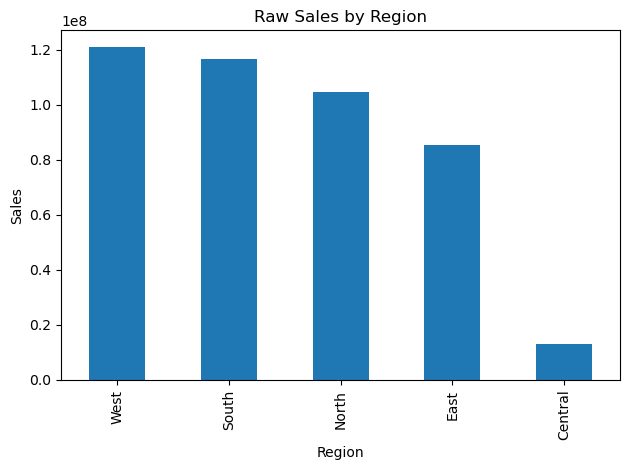

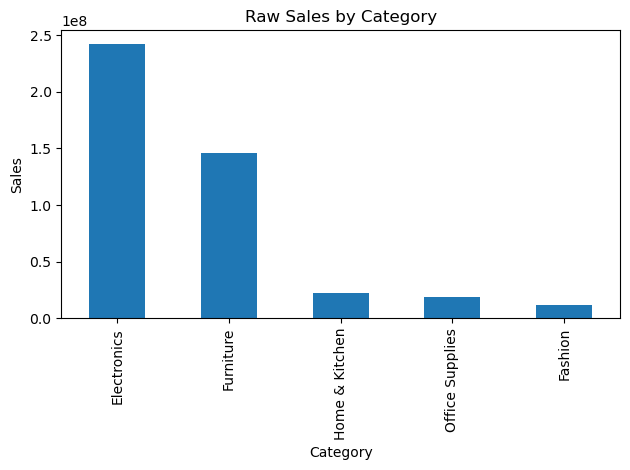

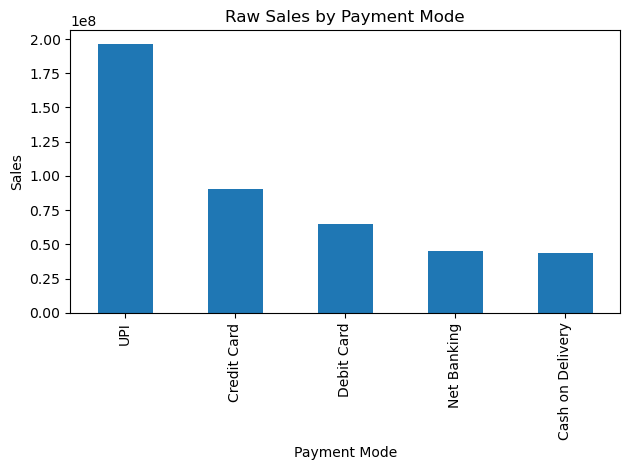

In [13]:
#EDA Charts 
raw_joined_df.groupby("region")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Raw Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

raw_joined_df.groupby("category")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Raw Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

raw_joined_df.groupby("payment_mode")["sales"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Raw Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [14]:
products_df.head()

,product_id,category,sub_category,product_name,min_price,max_price,base_margin
0,P001,Electronics,Mobiles,Samsung Galaxy M Series,"12,999.00","24,999.00",0.18
1,P002,Electronics,Mobiles,Redmi Note Series,"9,999.00","21,999.00",0.17
2,P003,Electronics,Mobiles,realme Narzo Series,"8,999.00","19,999.00",0.16
3,P004,Electronics,Laptops,Lenovo IdeaPad Laptop,"38,999.00","74,999.00",0.14
4,P005,Electronics,Laptops,HP Pavilion Laptop,"45,999.00","89,999.00",0.15
